In [5]:
import ipyparallel as ipp

# Create and start a cluster with 2 MPI engines
cluster = ipp.Cluster(engines="mpi", n=2)
rc = cluster.start_and_connect_sync()

# Activate the client to use all engines
rc.activate()
print(f"Connected to {len(rc.ids)} engines.")

Starting 2 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:06<00:00,  3.02s/engine]
Connected to 2 engines.


[stdout:0] ..... use MPI reader (size=2)
Rank 0/2 running on host: JunminD023sMBP5.localdomain, PID: 41991


[stdout:1] Rank 1/2 running on host: JunminD023sMBP5.localdomain, PID: 41992


[output:0]

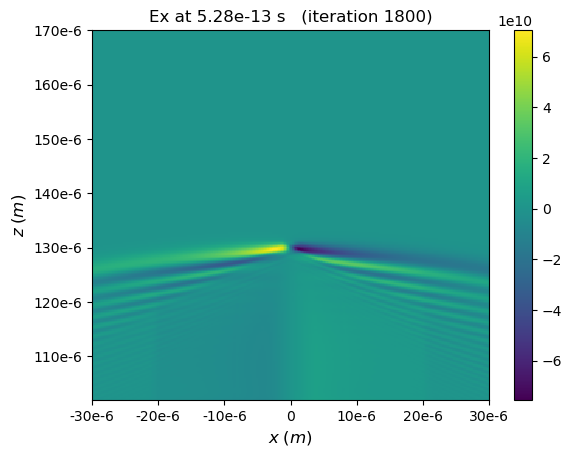

In [6]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries

#h5_2d_dir=f'/Users/dec2023/Work/2026/cursor/openPMD-viewer/tests/dataset/example-2d/hdf5/'
#ts = OpenPMDTimeSeries(h5_2d_dir)
file2d_dir=f'/Users/dec2023/Work/2025/Sept/Tests/PerformanceRun/master/diags/diag1/'
ts = OpenPMDTimeSeries(file2d_dir)

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()
host = os.uname().nodename

print(f"Rank {rank}/{size} running on host: {host}, PID: {os.getpid()}")
Ex, info_Ex = ts.get_field( iteration=1800, field='E', coord='x', plot=True ) 

[stdout:0] ..... use MPI reader (size=2)


[output:0]

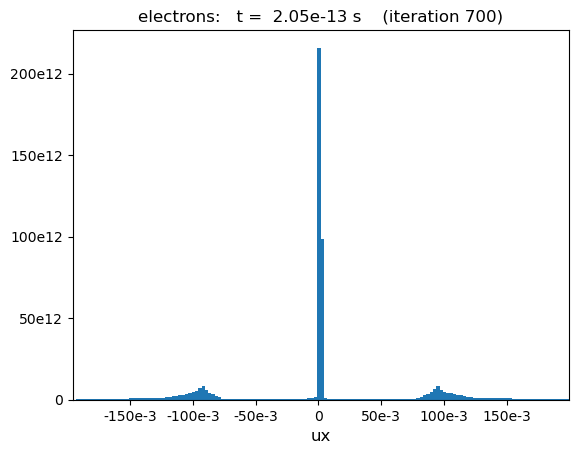

In [7]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries

#h5_2d_dir=f'/Users/dec2023/Work/2026/cursor/openPMD-viewer/tests/dataset/example-2d/hdf5/'
#ts = OpenPMDTimeSeries(h5_2d_dir)
file2d_dir=f'/Users/dec2023/Work/2025/Sept/Tests/PerformanceRun/master/diags/diag1/'
ts = OpenPMDTimeSeries(file2d_dir)

ux = ts.get_particle( var_list=['ux'], iteration=700, species='electrons', plot=True )
#z, uz = ts.get_particle( var_list=['x','uy'], iteration=1800, species='electrons', plot=True, vmax=3e12 )

[stdout:0] ..... use MPI reader (size=2)


[output:0]

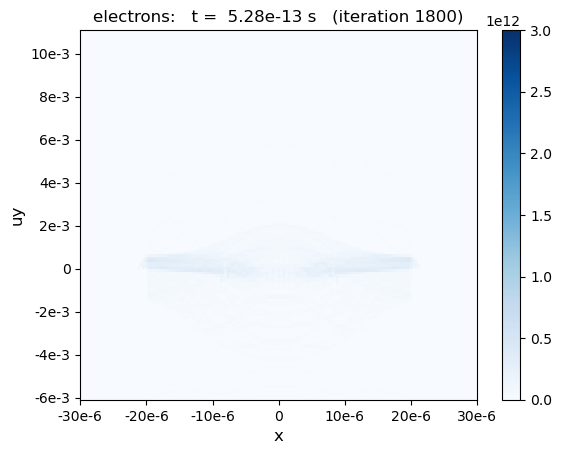

In [8]:
%%px
import mpi4py.MPI as MPI
import os

from openpmd_viewer import OpenPMDTimeSeries

#h5_2d_dir=f'/Users/dec2023/Work/2026/cursor/openPMD-viewer/tests/dataset/example-2d/hdf5/'
#ts = OpenPMDTimeSeries(h5_2d_dir)
file2d_dir=f'/Users/dec2023/Work/2025/Sept/Tests/PerformanceRun/master/diags/diag1/'
ts = OpenPMDTimeSeries(file2d_dir)

#ux = ts.get_particle( var_list=['ux'], iteration=700, species='electrons', plot=True )
x, uy = ts.get_particle( var_list=['x','uy'], iteration=1800, species='electrons', plot=True, vmax=3e12 )

[stdout:0] ..... use MPI reader (size=2)


[output:0]

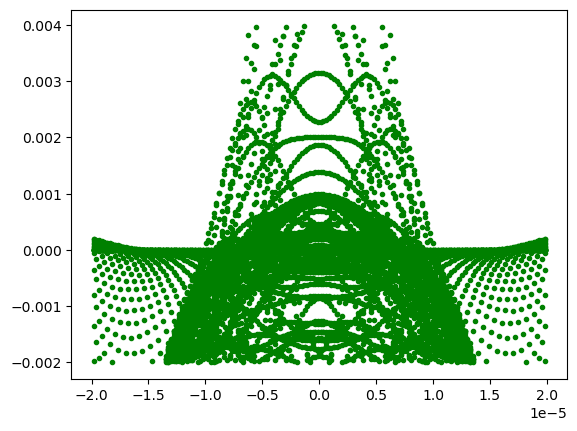

In [10]:
%%px
%matplotlib inline
import mpi4py.MPI as MPI
import os
import matplotlib.pyplot as plt
import numpy as np

from openpmd_viewer import OpenPMDTimeSeries

#h5_2d_dir=f'/Users/dec2023/Work/2026/cursor/openPMD-viewer/tests/dataset/example-2d/hdf5/'
#ts = OpenPMDTimeSeries(h5_2d_dir)
file2d_dir=f'/Users/dec2023/Work/2025/Sept/Tests/PerformanceRun/master/diags/diag1/'
ts = OpenPMDTimeSeries(file2d_dir)

x_selected, uy_selected = ts.get_particle( ['x', 'uy'], species='electrons', 
                            iteration=300, select={'uy':[-0.002, 0.004]} )
if (rank == 0):
    plt.plot(x_selected, uy_selected, 'g.')